# Optimal Clustering Analysis

In [20]:
import os, sys
import polars as pl
import numpy as np
from db_robust_clust.models import SampleDistClustering
from db_robust_clust.plots import clustering_MDS_plot_one_method
from kmedoids import KMedoids
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from robust_mixed_dist.quantitative import euclidean_dist_matrix

pl.Config.set_fmt_str_lengths(5000)

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')

sys.path.append(project_path)

from src.utils.data_analysis_utils import (
    plot_quant_comparison,
    plot_cat_comparison
)

processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '06_processed_data.parquet')
processed_data = pl.read_parquet(processed_data_path)

In [21]:
def get_medoid_and_knn_by_cluster(clust_object, knn_k=10):

    medoid_and_knn_by_cluster = {}

    for cluster_label in np.unique(clust_object.labels_):
        # Máscara e índices del cluster en espacio D
        cluster_mask = clust_object.labels_[clust_object.sample_idx] == cluster_label
        cluster_indices = np.where(cluster_mask)[0]

        # Medoide del cluster en espacio D
        medoid_idx_dist_matrix = clust_object.medoid_indices_[cluster_label]

        # Distancias del medoide a todos los puntos del cluster
        distances_to_medoid = D[medoid_idx_dist_matrix, cluster_indices]

        # Ordenar por distancia e incluir medoide (posición 0)
        sorted_positions = np.argsort(distances_to_medoid)
        knn_indices_dist_matrix = cluster_indices[sorted_positions[0:knn_k+1]]
        knn_indices_input_data = clust_object.sample_idx[knn_indices_dist_matrix]

        medoid_and_knn_by_cluster[cluster_label] = knn_indices_input_data

    return medoid_and_knn_by_cluster

In [22]:
QUANT_COMPARISON_COLS = [
    'political_stance_score', 
    'argument_quality_score', 
    'sentiment_score',
    #########################
    'post_score',
    'post_upvote_ratio',
    'post_num_comments',
    'comment_score'
]

CAT_COMPARISON_COLS = [
    'discourse_tone_score_label', 
    'dominant_frame_score_label', 
    'argument_quality_score_label', 
    'sentiment_score_label', 
    'political_stance_score_label',
    #########################
    'post_subreddit'
]

CAT_COMPARISON_ORDER = {
    'political_stance_score_label': [
        'Strongly Pro-Palestine',
        'Leaning Pro-Palestine',
        'Neutral / Balanced',
        'Leaning Pro-Israel',
        'Strongly Pro-Israel'
    ],
    'sentiment_score_label': [
        'Very Negative',
        'Moderately Negative',
        'Mildly Negative',
        'Neutral',
        'Mildly Positive',
        'Moderately Positive',
        'Very Positive',
    ],
    'argument_quality_score_label': [
        'Spam / Non-Argument',
        'Pure Reaction', 
        'Bare Opinion',
        'Justified Opinion',
        'Reasoned Argument',
        'Sophisticated Discourse'
    ]
}

KNN_K = 10

## Clustering Óptimo

In [23]:
embeddings_cols = [col for col in processed_data.columns if 'embedding' in col]

numerical_cols = ['sentiment_score'] + embeddings_cols

ordinal_cols = [
    'argument_quality_score',
    'political_stance_score',
]

nominal_cols = [
    'discourse_tone_score',
    'dominant_frame_score',
]

QUANT_COLS = numerical_cols
BINARY_COLS = []
MULTICLASS_COLS = nominal_cols + ordinal_cols

N_CLUSTERS = 4
KMEDOIDS_METHOD = 'pam'
METRIC = 'ggower'
D1 = 'robust_mahalanobis'
D2 = 'sokal'
D3 = 'hamming'
ROBUST_METHOD = 'trimmed'
ALPHA = 0.05
FRAC_SAMPLE_SIZE = 0.15

In [ ]:
p1 = len(QUANT_COLS)
p2 = len(BINARY_COLS)
p3 = len(MULTICLASS_COLS)

X = processed_data[QUANT_COLS + BINARY_COLS + MULTICLASS_COLS]

clustering_method = KMedoids(
    n_clusters=N_CLUSTERS, 
    metric='precomputed', 
    method=KMEDOIDS_METHOD, 
    init='build', 
    max_iter=100, 
    random_state=123
)

clust_object = SampleDistClustering(
    clustering_method = clustering_method,
    metric = METRIC,
    frac_sample_size=FRAC_SAMPLE_SIZE,
    random_state=123,
    stratify=False,
    p1=p1, p2=p2, p3=p3,
    d1=D1, d2=D2, d3=D3, 
    robust_method=ROBUST_METHOD, alpha=ALPHA
)

clust_object.fit(X)

# Time 15 mins

,clustering_method,KMedoids(init...dom_state=123)
,metric,'ggower'
,frac_sample_size,0.15
,random_state,123
,stratify,False
,p1,51
,p2,0
,p3,4
,d1,'robust_mahalanobis'
,d2,'sokal'
,d3,'hamming'


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


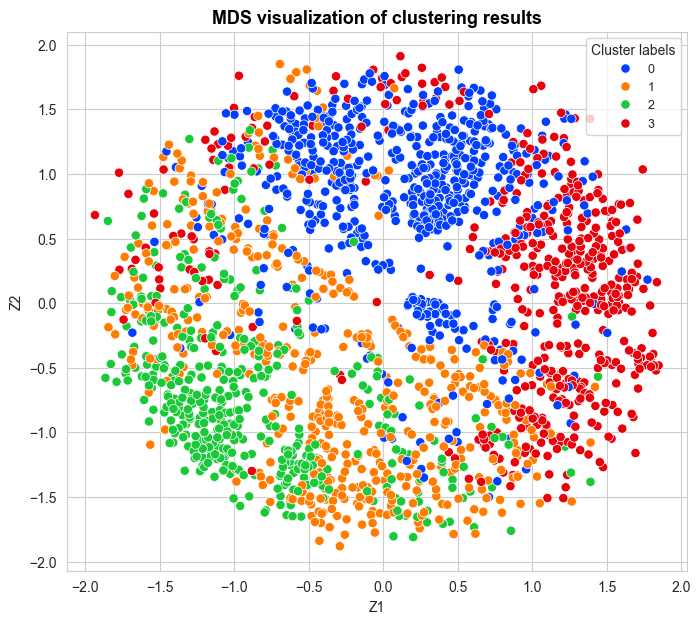

In [24]:
clust_labels = clust_object.labels_
D, D1, D2, D3 = clust_object.dist_output
sample_idx = clust_object.sample_idx

n_reduced = 2000

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=123) 

X_mds = mds.fit_transform(D[:n_reduced, :n_reduced])

clustering_MDS_plot_one_method(X_mds=X_mds, 
                            y_pred=clust_labels[sample_idx[:n_reduced]], 
                            y_true=None, title="MDS visualization of clustering results", 
                            accuracy=None, time=None, 
                            figsize=(8,7), bbox_to_anchor=(1,1), 
                            title_size=13, title_weight='bold', 
                            points_size=45, title_height=1, 
                            save=False, legend_size=9)

In [ ]:
##################################################################################################

processed_data = processed_data.with_columns(
    pl.lit(clust_labels).cast(pl.String).alias('clust_labels')
)

##################################################################################################

plot_quant_comparison(
    figsize=(12, 4),
    df=data,
    comparisons=[
        [col] for col in QUANT_COMPARISON_COLS
    ],
    group_by="clust_labels",
    showfliers=True,
    title='',
    labelbottom=True,
    xlabel_rotation=0,
    bbox_to_anchor=(0.5, -0.12)
)

##################################################################################################

plot_cat_comparison(
    figsize=(12, 4),
    df=data, 
    comparisons=[
        [col] for col in CAT_COMPARISON_COLS 
    ], 
    title="",
    bbox_to_anchor=(0.5,-0.07),
    group_by="clust_labels",
    max_cols=3,
    x_rotation=0,
    orientation='h',
    order=CAT_COMPARISON_ORDER
)

##################################################################################################

In [ ]:
medoid_and_knn_by_cluster = get_medoid_and_knn_by_cluster(clust_object, knn_k=KNN_K)

for cluster_label in np.unique(clust_object.labels_):
        
    print('-'*50)
    print(f'Medoid and KNN for Cluster {cluster_label}:\n')
    print('-'*50)
    display(processed_data[medoid_and_knn_by_cluster[cluster_label], ['post_title', 'post_body', 'comment_body'] + CAT_COMPARISON_COLS])


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


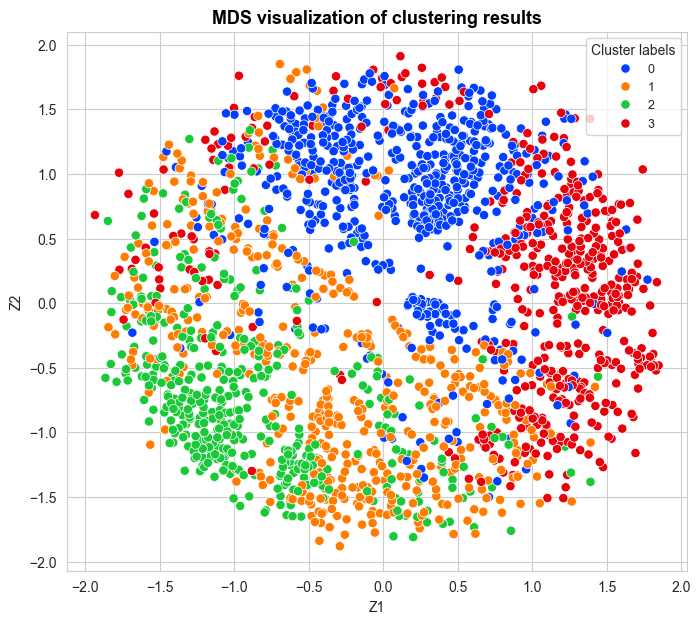

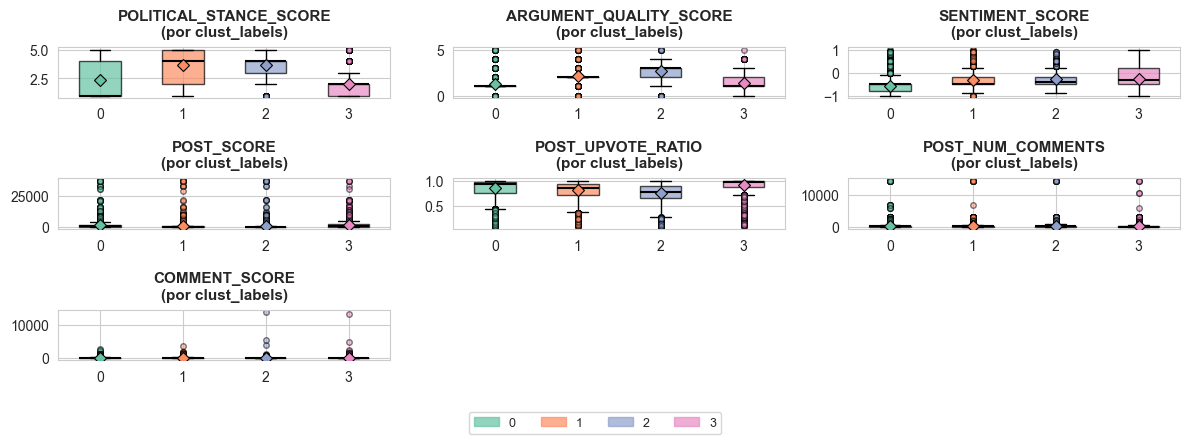

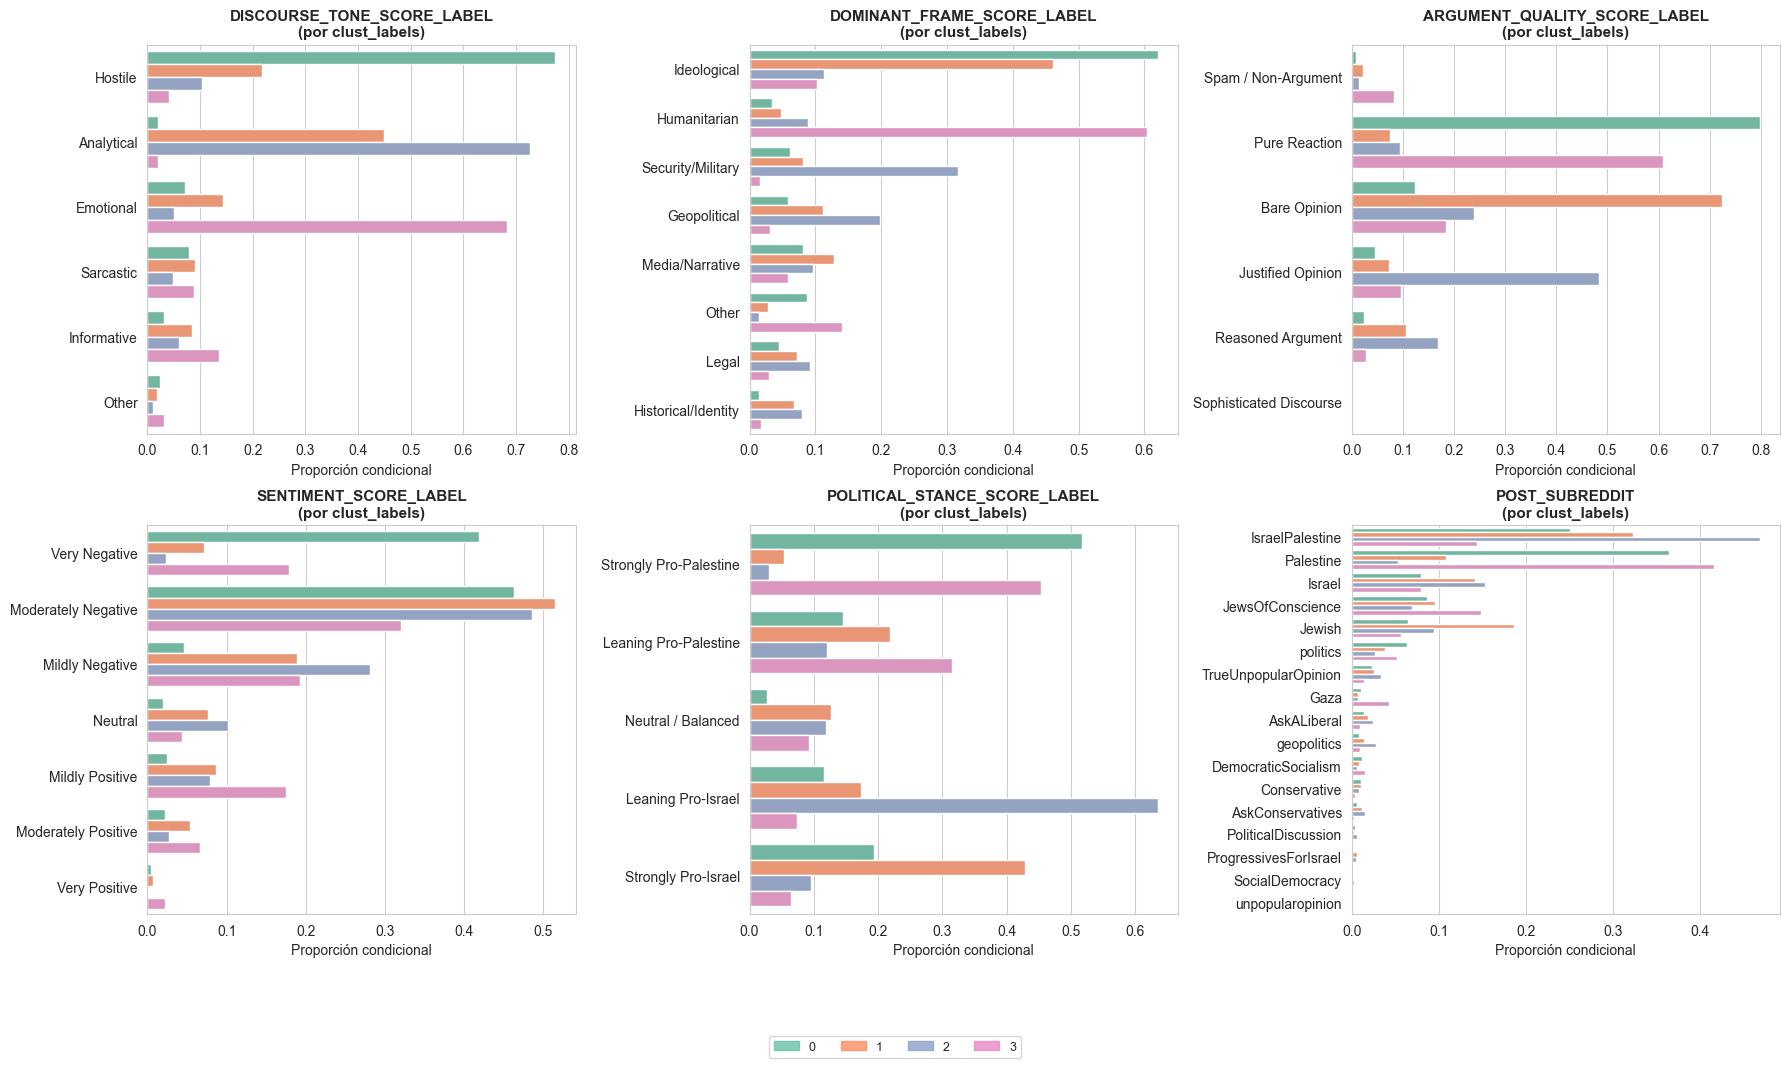

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------


shape: (11, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ post_titl ┆ post_body ┆ comment_b ┆ discourse ┆ … ┆ argument_ ┆ sentiment ┆ political ┆ post_sub │
│ e         ┆ ---       ┆ ody       ┆ _tone_sco ┆   ┆ quality_s ┆ _score_la ┆ _stance_s ┆ reddit   │
│ ---       ┆ str       ┆ ---       ┆ re_label  ┆   ┆ core_labe ┆ bel       ┆ core_labe ┆ ---      │
│ str       ┆           ┆ str       ┆ ---       ┆   ┆ l         ┆ ---       ┆ l         ┆ str      │
│           ┆           ┆           ┆ str       ┆   ┆ ---       ┆ str       ┆ ---       ┆          │
│           ┆           ┆           ┆           ┆   ┆ str       ┆           ┆ str       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ If Pro-Pa ┆ This is   ┆ Israel IS ┆ Hostile   ┆ … ┆ Pure      ┆ Very      ┆ Strongly  ┆ IsraelPa │
│ lestine   ┆ an honest ┆ THE BAD   ┆           ┆   ┆ Reaction  ┆ Negative  ┆ Pro-Pales ┆ lestine  │
│ “empathy” ┆ to god    ┆ GUY. Why  ┆           ┆   ┆           ┆           ┆ tine      ┆          │
│ leads to  ┆ question  ┆ you ask?  ┆           ┆   ┆           ┆           ┆           ┆          │
│ more      ┆ as I      ┆ 70,000    ┆           ┆   ┆           ┆           ┆           ┆          │
│ deaths,   ┆ genuinely ┆ killed by ┆           ┆   ┆           ┆           ┆           ┆          │
│ what are  ┆ do not    ┆ Israel in ┆           ┆   ┆           ┆           ┆           ┆          │
│ we        ┆ understan ┆ response  ┆           ┆   ┆           ┆           ┆           ┆          │
│ actually  ┆ d how     ┆ to an     ┆           ┆   ┆           ┆           ┆           ┆          │
│ supportin ┆ people    ┆ attack.   ┆           ┆   ┆           ┆           ┆           ┆          │
│ g?        ┆ can look  ┆ Lands     ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ at this   ┆ stolen    ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ conflict  ┆ and       ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ and       ┆ continue  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ conclude  ┆ to be     ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ that      ┆ stolen    ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ Israel is ┆ from Pale ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ “the bad  ┆ stinians  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ guy.” The ┆ in the    ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ war       ┆ West      ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ itself is ┆ Bank.     ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ tragic    ┆ Simple.   ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ and       ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ nobody    ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ with a    ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ sense of  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ humanity  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ celebrate ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ s it, but ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ when you  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ look at   ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ the last  ┆           ┆         

--------------------------------------------------
Medoid and KNN for Cluster 1:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label,post_subreddit
str,str,str,str,str,str,str,str,str
"""Saw someone on Reddit say “Israel is genuinely a sociopathic society” and I am disgusted""","""I was lurking on a Reddit thread and saw someone say that “Israel is genuinely a sociopathic society.” It hit me like a punch to the gut. Calling an entire society sociopathic? This is blatant antisemitism. As if there’s not a single Israeli citizen who doesn’t protest the current government? As if there’s no dissent, no nuance, no humanity? What they’re saying is “all Israelis are sociopaths “ which then means that all Jews are sociopaths. I’m Jewish. I’ve always considered myself on the left, but I’ve been feeling increasingly alienated. It’s exhausting to constantly see dehumanizing rhetoric, to watch people who claim to care about justice repeat antisemitic talking points, and to be told directly or indirectly that my life, my people, my pain don’t matter. I’m so sick and tired of antisemitism becoming normal. ""","""Most of them are misinformed about the Israel/Palestine conflict. They believe Palestinians are indigenous to the area. They believe Jews stole the land that is now Israel. They believe the U.S. armed Israel in her war for independence. They believe Israel is a theocracy. They believe the West Bank is on the west side of Palestine, and that's why it's called the ""west bank."" They believe that Israel was gifted to the Jews by the U.N. They lie about Israel and Palestinians for the same reason conservatives lie to defend Trump and the GOP. They lie because they can't defend their opinions using facts and logic.""","""Analytical""","""Ideological""","""Bare Opinion""","""Mildly Negative""","""Strongly Pro-Israel""","""Jewish"""
"""Feeling really disturbed at the current Israel discourse on Reddit""","""I’m sure many of you have already gotten to this point way before the most recent incident with Israel and Iran but I’ve just been gobsmacked at how the overwhelming majority of Reddit is just straight up pro Iran getting nukes/anti Israel and gleeful in the paradigm that “Israel deserved it and anything that happens to them” based off the issues in Gaza. I feel like I’m taking crazy pills where no one is aware of the entire history of this conflict and why Israel operates the way it does with it’s preventative attacks. I can’t tell if it’s a genuine hatred of Israel, an ignorance of history, remnants of all the anti Israel misinformation and brainwashing shoved at Gen Z through avenues such as TikTok. I go over to the conservative subreddit and somehow they are the only ones thinking logically about this situation amidst all their lunacy. I feel so lost as a liberal jew Zionist. I can’t tell what’s up or down anymore, it really feels like this site is starting to go down the deep end. EDIT: I know a lot of you are saying its just bots, but the point is that what started as bots has now transitioned to normal real people with these views. Just last night someone in SF was assaulted for confronting a bunch of drunk guys shouting ""fuck jews"". Anti-zionism and anti-semitism is becoming mainstream on reddit and mainstream IRL. https://www.sfchronicle.com/crime/article/man-assaulted-friend-decries-attack-as-antisemitic-20378435.php""","""It’s just basic Jew hatred, same as what our grandparents faced. Just slightly repackaged. Why do I think this? Because in their minds children in Gaza and Iran are innocent, yet Jewish children in Israel are somehow tainted at birth. Collective punishment is wrong, except for when it comes to Jews and Israelis. They condemn the KKK yet repeat their tropes (“Zio”). Etc. There’s no logic to it. It’s just pure Jew hatred. ""","""Hostile""","""Ideological""","""Bare Opinion""","""Very Negative""","""Strongly Pro-Israel""","""Jewish"""
"""Feeling really disturbed at the curre

--------------------------------------------------
Medoid and KNN for Cluster 2:

--------------------------------------------------


shape: (11, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ post_titl ┆ post_body ┆ comment_b ┆ discourse ┆ … ┆ argument_ ┆ sentiment ┆ political ┆ post_sub │
│ e         ┆ ---       ┆ ody       ┆ _tone_sco ┆   ┆ quality_s ┆ _score_la ┆ _stance_s ┆ reddit   │
│ ---       ┆ str       ┆ ---       ┆ re_label  ┆   ┆ core_labe ┆ bel       ┆ core_labe ┆ ---      │
│ str       ┆           ┆ str       ┆ ---       ┆   ┆ l         ┆ ---       ┆ l         ┆ str      │
│           ┆           ┆           ┆ str       ┆   ┆ ---       ┆ str       ┆ ---       ┆          │
│           ┆           ┆           ┆           ┆   ┆ str       ┆           ┆ str       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ If Pro-Pa ┆ This is   ┆ I agree,  ┆ Analytica ┆ … ┆ Justified ┆ Mildly    ┆ Leaning   ┆ IsraelPa │
│ lestine   ┆ an honest ┆ which is  ┆ l         ┆   ┆ Opinion   ┆ Negative  ┆ Pro-Israe ┆ lestine  │
│ “empathy” ┆ to god    ┆ why while ┆           ┆   ┆           ┆           ┆ l         ┆          │
│ leads to  ┆ question  ┆ I say     ┆           ┆   ┆           ┆           ┆           ┆          │
│ more      ┆ as I      ┆ that I’m  ┆           ┆   ┆           ┆           ┆           ┆          │
│ deaths,   ┆ genuinely ┆ pro-Pales ┆           ┆   ┆           ┆           ┆           ┆          │
│ what are  ┆ do not    ┆ tine at   ┆           ┆   ┆           ┆           ┆           ┆          │
│ we        ┆ understan ┆ this      ┆           ┆   ┆           ┆           ┆           ┆          │
│ actually  ┆ d how     ┆ point of  ┆           ┆   ┆           ┆           ┆           ┆          │
│ supportin ┆ people    ┆ the war   ┆           ┆   ┆           ┆           ┆           ┆          │
│ g?        ┆ can look  ┆ because I ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ at this   ┆ think     ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ conflict  ┆ Israel    ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ and       ┆ needs to  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ conclude  ┆ be restra ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ that      ┆ ined, so  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ Israel is ┆ there is  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ “the bad  ┆ an        ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ guy.” The ┆ incentive ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ war       ┆ to end    ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ itself is ┆ the war,  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ tragic    ┆ I’ll      ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ and       ┆ never be  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ nobody    ┆ an anti-Z ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ with a    ┆ ionist. I ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ sense of  ┆ think the ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ humanity  ┆ fears     ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ celebrate ┆ that      ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ s it, but ┆ Israeli   ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ when you  ┆ Jews have ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ look at   ┆ against   ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ the last  ┆ their     ┆         

--------------------------------------------------
Medoid and KNN for Cluster 3:

--------------------------------------------------


post_title,post_body,comment_body,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,political_stance_score_label,post_subreddit
str,str,str,str,str,str,str,str,str
"""The most disturbing story you'll hear today: Israel killed the family of a Gaza surgeon, Dr. Khalid, forcing him to watch it live.""","""Source in the comments. ""","""This is the shit their doing that we know about. Imagine what theure doing that we don't know about.""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Moderately Negative""","""Strongly Pro-Palestine""","""Palestine"""
"""Israel used US-supplied thermal Weapons that burn at 3,500C to Murder thousands of Palestinians, the people evaporated.""","""""","""They no longer want bodies to be the only witness to their atrocities, what is happening? How can we let this go on?""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Moderately Negative""","""Strongly Pro-Palestine""","""Gaza"""
"""This is how a normal day in Gaza looks like""","""""","""Israel bombs and murders people in brutally violent ways, then tries to justify it afterwards by claiming they were ‘acting.’ It’s sick and evil.""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine""","""Palestine"""
"""The IDF has been carrying out this depraved stunt to lure and kill Palestinians since April last year...""","""""","""At this point they are trying to be the most evil people on earth. I mean the abuse they are trying to exert on Palestinians has passed the holocaust in cruelty. They are playing with Gaza’s before they kill them and it’s all for their own pleasure. And this only based on what we know, imagine what we will learn when this is all over.""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine""","""Palestine"""
"""The Gaza holocaust""","""""","""They're purposefully AIMING for children https://youtu.be/U5k_Sw_UNpo?si=JXtUCDIyAsWiAwHX The plan for Isreal is to murder the children in order to prevent the Gazans from reproducing. Trully despicable""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine""","""Palestine"""
…,…,…,…,…,…,…,…,…
"""Israel is killing 100 Palestinians every day and the mainstream media barely reports it. They’ve normalized daily massacres.""","""""","""Plus there are a bunch of hasbaraists right now reporting that gazans are soooo thankful for food that they are been given by the US, as if they haven't been bombed and starved and burying their children because of them. I really had it with humans.""","""Emotional""","""Humanitarian""","""Pure Reaction""","""Very Negative""","""Strongly Pro-Palestine""","""Palestine"""
"""'It's a Killing Field': IDF Soldiers Ordered to Shoot Deliberately at Unarmed Gazans Waiting for Humanitarian Aid""","""Haaretz Exposé IDF Soldiers Ordered to Target Unarmed Civilians in Gaza Proof of Systematic Killing https://archive.is/20250627130556/https://www.haaretz.com/israel-news/2025-06-27/ty-article-magazine/.premium/idf-soldiers-ordered-to-shoot-deliberately-at-unarmed-gazans-waiting-for-humanitarian-aid/00000197-ad8e-de01-a39f-ffbe33780000 A bombshell Haaretz investigation reveals Israeli soldiers admitting they were ordered to deliberately shoot unarmed Palestinians at Gaza aid sites even when crowds posed zero threat. Testimonies describe a killing field where 1 to 5 civilians were gunned down daily using heavy machine guns mortars and tank fire instead of non lethal crowd control. One soldier bluntly stated We communicate with them through fire. The report exposes a chilling normalization of slaughter commanders labeled the operation Salted Fish a twisted reference to a children’s game while a senior officer admitted They were just killed for nothing. Over 549 Palestinians have been killed near aid centers since May with 4000 plus wounded most shot while scrambli

In [18]:
processed_data = get_SampleDistClustering_results(clust_object, processed_data, QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER)

In [12]:
processed_data.head()

comment_id,post_id,comment_body,comment_score,comment_created_utc,comment_created_date,post_subreddit,post_title,post_body,post_score,post_upvote_ratio,post_num_comments,post_created_utc,post_created_date,post_url,extraction_query,extraction_sort,extraction_time,text_content,content_relevance_score,reasoning_content_relevance_score,argument_quality_score,reasoning_argument_quality_score,discourse_tone_score,reasoning_discourse_tone_score,dominant_frame_score,reasoning_dominant_frame_score,political_stance_score,reasoning_political_stance_score,sentiment_score,reasoning_sentiment_score,embedding_pca_01,embedding_pca_02,embedding_pca_03,embedding_pca_04,embedding_pca_05,embedding_pca_06,…,embedding_pca_20,embedding_pca_21,embedding_pca_22,embedding_pca_23,embedding_pca_24,embedding_pca_25,embedding_pca_26,embedding_pca_27,embedding_pca_28,embedding_pca_29,embedding_pca_30,embedding_pca_31,embedding_pca_32,embedding_pca_33,embedding_pca_34,embedding_pca_35,embedding_pca_36,embedding_pca_37,embedding_pca_38,embedding_pca_39,embedding_pca_40,embedding_pca_41,embedding_pca_42,embedding_pca_43,embedding_pca_44,embedding_pca_45,embedding_pca_46,embedding_pca_47,embedding_pca_48,embedding_pca_49,embedding_pca_50,political_stance_score_label,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label,clust_labels
str,str,str,i64,f64,"datetime[μs, UTC]",str,str,str,i64,f64,i64,f64,"datetime[μs, UTC]",str,str,str,"datetime[μs, UTC]",str,i64,str,i64,str,i64,str,i64,str,i64,str,f64,str,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str
"""oc4zaua""","""1s1mro9""","""Israel has all the conditions it needs to reject any solution. It seeks domination, destruction and total subjugation of its neighbours. This will not last forever, though. """,-6,1.7743e9,2026-03-24 02:49:52 UTC,"""IsraelPalestine""","""AMA: I am an american Zionist jew who believes in a 2 state solution.""","""Like basically every American Jew I know (and I know many... like half of my friends are jews from the various synagogues i've belonged to in my life), I am a reform jew that went through hebrew school as a child, was bar mitzvahed, stopped giving a shit about judaism after, and then rediscovered my faith and reengaged with the community as an adult when I got married and had a kid. I do not speak hebrew. I have never read a word of the talmud. In fact, every thing I have learned about the Talmud I learned from people like Candace Owens and others who use this text - which is ""central to demonic jewish doctrine"" apparently - to smear us all as jewish supremicists. Also like every jew I know, I hate netanyahu. I hate what settlers are doing in the west bank. And I am increasingly frustrated by the way Israel continuously makes things worse in the region. I'm writing this in good faith because I want to actually engage and clear things up and clarify and also understand more about why people feel the way they do. Please don't use this as an opportunity to spew more vitriol and awfulness at me. If there's one thing I'm sure of, it's that me and people like me are NOT your enemy. Ask me anything.""",78,0.78,438,1.7743e9,2026-03-23 17:05:40 UTC,"""https://www.reddit.com/r/IsraelPalestine/comments/1s1mro9/ama_i_am_an_american_zionist_jew_who_believes_in/""","""Conflict/Security""","""new""",2026-03-26 10:09:05.123482 UTC,"""Post Title: AMA: I am an american Zionist jew who believes in a 2 state solution. Post Body: Like basically every American Jew I know (and I know many... like half of my friends are jews from the various synagogues i've belonged to in my life), I am a reform jew that went through hebrew school as a child, was bar mitzvahed, stopped giving a shit about judaism after, and then rediscovered my faith and reengaged with the community as an adult when I got married and had a kid. I do not speak h

##  TO DO: usar variables de contexto de reddit para ampliar el analisis de la configuración de clustering óptima/elegida.

## TO DO: añadir nube de palabras y analitac basadas en NLP más tradcional sobre la configuración de clustering óptima/elegida.